
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>

In [ ]:

<div class="alert alert-block alert-success"> 
<b>COMENTARIO GENERAL #1</b> <a class="tocSkip"></a>

Felicidades Migu! Tu trabajo es excelente. 

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [53]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, levene, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest


In [54]:

# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')


**Vista previa e información general del conjunto de datos**

In [55]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [56]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB



✍️ **Comentario**: 

El dataset contiene 40.000 registros y 9 columnas. Según la revisión inicial con df.info(), no se observan valores nulos, ya que todas las columnas tienen 40.000 valores no nulos.

Las variables categóricas como user_id, date, landing, region, dispositivo, traffic_source y user_type aparecen como tipo object. La variable converted está en formato entero (int64), lo cual es adecuado porque representa una conversión binaria con valores 0 y 1. La variable gasto está en formato numérico decimal (float64), adecuado para comparar montos gastados.

La columna date aparece como tipo object; si se realizara un análisis temporal, podría convertirse a formato fecha con pd.to_datetime(). Para el análisis principal del experimento A/B, se puede continuar con las columnas actuales.

Como gasto es 0 cuando el usuario no convierte, para comparar el gasto promedio entre las páginas A y B se filtrarán únicamente los usuarios con converted == 1.


<div class="alert alert-block alert-success">
<b>Exploracion Inicial</b> <a class="tocSkip"></a>

Excelente! Utilizaste correctamente head() e info() para obtener una primera vista del dataset. 


</div>

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [57]:
# Verificar usuarios únicos
print("Total de filas:", len(df))
print("Usuarios únicos:", df["user_id"].nunique())
print("Usuarios duplicados:", df["user_id"].duplicated().sum())

Total de filas: 40000
Usuarios únicos: 40000
Usuarios duplicados: 0


 **Variable `date`**  
Explorar rango de fechas

In [58]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [59]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [60]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [61]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [62]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df["landing"].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


<div class="alert alert-block alert-success">
<b>Validacion de Variables</b> <a class="tocSkip"></a>

Revisaste correctamente las variables clave usando describe() y value_counts(). Esto asegura que los datos estan en el formato esperado antes de continuar con el analisis estadistico.

</div>

✍️ **Comentario**: La variable landing contiene las dos categorías esperadas del experimento A/B: página A y página B.

El conteo muestra que la página B tiene 20.018 usuarios y la página A tiene 19.982 usuarios. La diferencia entre ambos grupos es muy pequeña, por lo que el experimento se considera balanceado entre las dos versiones de la landing page.
No se observan categorías mal escritas ni valores inesperados en la variable landing, así que se puede continuar con el análisis estadístico del experimento.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [63]:
# Gasto por versión
gasto_A = df[(df["converted"] == 1) & (df["landing"] == "A")]["gasto"]
gasto_B = df[(df["converted"] == 1) & (df["landing"] == "B")]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

<div class="alert alert-block alert-success">
<b>Filtro de Clientes y Gasto Promedio</b> <a class="tocSkip"></a>

Filtraste correctamente solo los usuarios convertidos (converted = 1).

</div>

### Prueba ...

**Hipótesis:**

- **Hipótesis nula (H₀):** el gasto promedio de los usuarios convertidos es igual entre la página A y la página B.
- **Hipótesis alternativa (H₁):** el gasto promedio de los usuarios convertidos es diferente entre la página A y la página B.

<div class="alert alert-block alert-success">
<b>Definicion de Hipotesis</b> <a class="tocSkip"></a>

Las hipotesis nula (H0) y alternativa (H1) estan correctamente formuladas y son coherentes con el objetivo del analisis. Una hipotesis bien planteada es la base de cualquier prueba estadistica rigurosa.

</div>

In [64]:
# Verificar igualdad de varianzas
l_stat, p_value_var = levene(gasto_A, gasto_B)

print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p Levene: {p_value_var}")

alpha = 0.05

if p_value_var < alpha:
    equal_var = False
    print("Se usan varianzas diferentes: equal_var=False")
else:
    equal_var = True
    print("Se asumen varianzas iguales: equal_var=True")

Estadístico de Levene: 29.17646453202917
Valor p Levene: 6.875301988016449e-08
Se usan varianzas diferentes: equal_var=False


<div class="alert alert-block alert-success">
<b>Prueba de Levene</b> <a class="tocSkip"></a>

Muy bien! Aplicaste correctamente la prueba de Levene para evaluar la homogeneidad de varianzas entre los grupos. Este paso es clave para determinar que version del t-test utilizar y demuestra un analisis estadistico riguroso y bien fundamentado.

</div>

In [65]:

# Aplicar prueba t
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=equal_var)

print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")


Estadístico t: -9.48101092267275
Valor p: 3.627602231521493e-21


<div class="alert alert-block alert-success">
<b>Test Estadistico — t-test</b> <a class="tocSkip"></a>

Aplicaste correctamente el t-test y reportaste tanto el estadistico t_stat como el p-value.

</div>

In [66]:
print("Gasto promedio A:", gasto_A.mean())
print("Gasto promedio B:", gasto_B.mean())
print("Diferencia A - B:", gasto_A.mean() - gasto_B.mean())

Gasto promedio A: 61.0865724522293
Gasto promedio B: 68.74536005009392
Diferencia A - B: -7.658787597864624


<div class="alert alert-block alert-success">
<b>Interpretacion — Gasto Promedio</b> <a class="tocSkip"></a>

Muy bien! La interpretacion del resultado es clara y esta redactada en terminos de negocio. 

Efectivamente debemos rechazar la hipótesis nula.

Explicaste correctamente el significado del p-value y lo vinculaste a una conclusion accionable sobre las landings.
</div>

### 📝 Conclusión e interpretación

**Decisión:** 
Como el valor p es menor que 0.05, se rechaza la hipótesis nula. Esto indica que existe evidencia estadística de una diferencia en el gasto promedio de los usuarios convertidos entre la página A y la página B.

**Interpretación de negocio:**  
Los resultados muestran que el gasto promedio no es igual entre ambas versiones de la landing page. Dado que el estadístico t es negativo al comparar gasto_A contra gasto_B, la página B presenta un gasto promedio mayor que la página A entre los usuarios que realizaron una conversión. Desde una perspectiva de negocio, esto sugiere que la página B podría generar mayor valor económico por usuario convertido.



---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba

**Hipótesis:**

- **Hipótesis nula (H₀):** la tasa de conversión es igual entre la página A y la página B.
- **Hipótesis alternativa (H₁):** la tasa de conversión es diferente entre la página A y la página B.

In [67]:
# Número de usuarios convertidos por página
conversiones = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:")
print(conversiones)

print("\nTotal de usuarios por página:")
print(totales)


Usuarios convertidos por página:
landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
landing
A    19982
B    20018
Name: converted, dtype: int64


<div class="alert alert-block alert-success">
<b>Calculo de Metricas — Tasa de Conversion</b> <a class="tocSkip"></a>

Calculaste correctamente la tasa de conversion para cada landing. Las metricas son precisas y estan bien presentadas, lo que facilita la comparacion entre los grupos del experimento A/B.

</div>

In [68]:
# Aplicar prueba
conteos = [conversiones["A"], conversiones["B"]]
num_observaciones = [totales["A"], totales["B"]]

z_stat, p_value = proportions_ztest(conteos, num_observaciones)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


In [69]:
tasa_A = conversiones["A"] / totales["A"]
tasa_B = conversiones["B"] / totales["B"]

print(f"Tasa de conversión A: {tasa_A:.4f}")
print(f"Tasa de conversión B: {tasa_B:.4f}")
print(f"Diferencia A - B: {tasa_A - tasa_B:.4f}")

Tasa de conversión A: 0.1257
Tasa de conversión B: 0.1596
Diferencia A - B: -0.0338


<div class="alert alert-block alert-success">
<b>Test Estadistico — z-test de Proporciones</b> <a class="tocSkip"></a>

Aplicaste correctamente el test para comparar las tasas de conversion entre las dos landings. Este es el test adecuado para comparar proporciones en muestras grandes y lo implementaste de forma precisa.

Efectivamente, rechazamos la hipótesis nula ya que hay evidencia de una dirferencia. 

</div>

### 📝 Conclusión e interpretación

**Decisión:**  
Como el valor p es menor que 0.05, se rechaza la hipótesis nula. Esto indica que existe evidencia estadística de una diferencia en la tasa de conversión entre la página A y la página B.

Interpretación de negocio:
La página B presenta una tasa de conversión mayor que la página A. La tasa de conversión de la página A es aproximadamente 0.1257, mientras que la de la página B es aproximadamente 0.1596. Esto significa que la página B convierte alrededor de 3.38 puntos porcentuales más que la página A.

Desde una perspectiva de negocio, la página B muestra mejor desempeño en conversión y podría generar más usuarios convertidos que la página A. Sin embargo, esta conclusión indica asociación estadística dentro del experimento y debe complementarse con el análisis de gasto promedio, tráfico y tipo de usuario antes de tomar una decisión final.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba 


**Hipótesis:**
- **Hipótesis nula (H₀):** la fuente de tráfico y la conversión son independientes; es decir, la conversión no depende de traffic_source.
- **Hipótesis alternativa (H₁):** la fuente de tráfico y la conversión no son independientes; es decir, existe una asociación entre traffic_source y converted

In [70]:
# Tabla de contingencia entre fuente de tráfico y conversión
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])

print(tabla_trafico)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [71]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)
# Visualizar resultados
print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")

Estadístico chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914
Grados de libertad: 3


In [72]:
# Tasa de conversión por fuente de tráfico
tasas_trafico = df.groupby("traffic_source")["converted"].mean().sort_values(ascending=False)
print(tasas_trafico)

traffic_source
Email       0.149927
Ads         0.147382
Referral    0.138812
Organic     0.137877
Name: converted, dtype: float64


<div class="alert alert-block alert-success">
<b>Interpretacion — Trafico y Conversion</b> <a class="tocSkip"></a>

El insight extraido sobre la relacion entre la fuente de trafico y la conversion es claro. Podemos decir que hay evidencia de asociación entre las variables. 

</div>

### 📝 Conclusión e interpretación

**Decisión:**  
Como el valor p es menor que 0.05, se rechaza la hipótesis nula. Esto indica que existe evidencia estadística de una asociación entre la fuente de tráfico (traffic_source) y la conversión (converted).

**Interpretación de negocio:**
Los resultados sugieren que la conversión no se distribuye exactamente igual entre todas las fuentes de tráfico. Según las tasas observadas, Email presenta la tasa de conversión más alta, aproximadamente 0.1499, seguido por Ads con 0.1474. Luego aparecen Referral con 0.1388 y Organic con 0.1379.

Aunque las diferencias no son extremadamente grandes, la prueba chi-cuadrada indica que existe una relación estadísticamente significativa entre la fuente de tráfico y la conversión. Desde una perspectiva de negocio, esto sugiere que canales como Email y Ads podrían estar generando usuarios con mayor probabilidad de conversión, por lo que conviene analizarlos con mayor detalle antes de optimizar la inversión de marketing.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba 
**Hipótesis:**

- **Hipótesis nula (H₀):** El tipo de usuario y la conversión son independientes; es decir, la conversión no depende de user_type.
- **Hipótesis alternativa (H₁):** el tipo de usuario y la conversión no son independientes; es decir, existe una asociación entre user_type y converted.

In [73]:
# Tabla de contingencia entre tipo de usuario y conversión
tabla_usuario = pd.crosstab(df["user_type"], df["converted"])

print(tabla_usuario)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [74]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)

# Visualizar resultados
print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")


Estadístico chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974
Grados de libertad: 1


In [75]:
# Tasa de conversión por tipo de usuario
tasas_usuario = df.groupby("user_type")["converted"].mean().sort_values(ascending=False)

print(tasas_usuario)


user_type
Nuevo         0.143587
Recurrente    0.140904
Name: converted, dtype: float64


<div class="alert alert-block alert-success">
<b>Interpretacion — Nuevos vs. Recurrentes</b> <a class="tocSkip"></a>

Excelente! Comparaste efectivamente el comportamiento de conversion entre usuarios nuevos y recurrentes, y tradujiste los hallazgos en una conclusion con valor estrategico. 

No rechazamos la hipótesis en este caso, ya que no hay evidencia suficiente de asociación entre las variables. 

</div>

### 📝 Conclusión e interpretación

**Decisión:**  
Como el valor p es mayor que 0.05, no se rechaza la hipótesis nula. Esto indica que no hay evidencia estadística suficiente para afirmar que exista una asociación significativa entre el tipo de usuario (`user_type`) y la conversión (`converted`).

**Interpretación de negocio:**  

Las tasas de conversión observadas son muy similares entre usuarios nuevos y recurrentes. Los usuarios nuevos presentan una tasa aproximada de 0.1436, mientras que los usuarios recurrentes presentan una tasa aproximada de 0.1409.

Aunque los usuarios nuevos muestran una tasa ligeramente mayor, la diferencia es pequeña y la prueba chi-cuadrada indica que no es estadísticamente significativa. Por lo tanto, con estos datos no se puede afirmar que el tipo de usuario influya de manera relevante en la conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

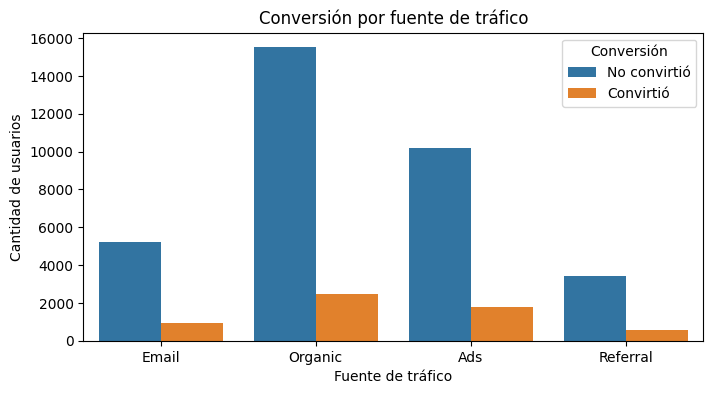

In [76]:
# Conteo de usuarios por fuente de tráfico y conversión
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="traffic_source", hue="converted")

plt.title("Conversión por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Cantidad de usuarios")
plt.legend(title="Conversión", labels=["No convirtió", "Convirtió"])
plt.show()

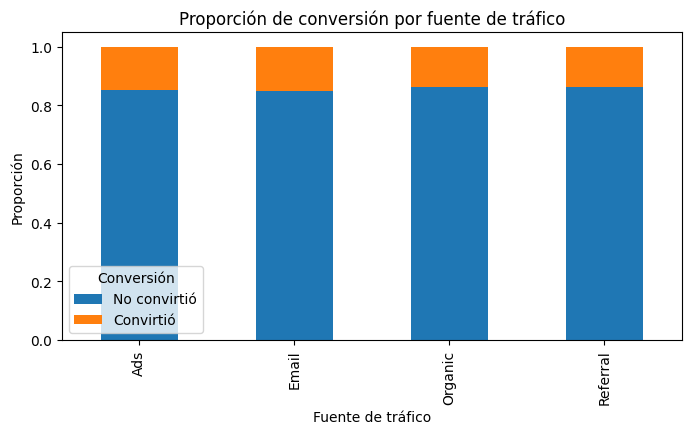

In [77]:
# Proporción de conversión por fuente de tráfico
tabla_trafico_prop = pd.crosstab(
    df["traffic_source"],
    df["converted"],
    normalize="index"
)

tabla_trafico_prop.plot(kind="bar", stacked=True, figsize=(8, 4))

plt.title("Proporción de conversión por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Proporción")
plt.legend(title="Conversión", labels=["No convirtió", "Convirtió"])
plt.show()

✍️ **Comentario**: 

Los gráficos muestran la relación entre la fuente de tráfico y la conversión. En el gráfico de conteos se observa el volumen absoluto de usuarios convertidos y no convertidos por canal, mientras que el gráfico de proporciones permite comparar mejor la efectividad relativa de cada fuente.

Aunque las diferencias visuales no son muy grandes, las tasas de conversión muestran que Email y Ads tienen un desempeño ligeramente superior frente a Referral y Organic. Esto coincide con la prueba chi-cuadrada, donde se encontró evidencia estadística de asociación entre traffic_source y converted.

### Relación entre el tipo de usuario y la conversión

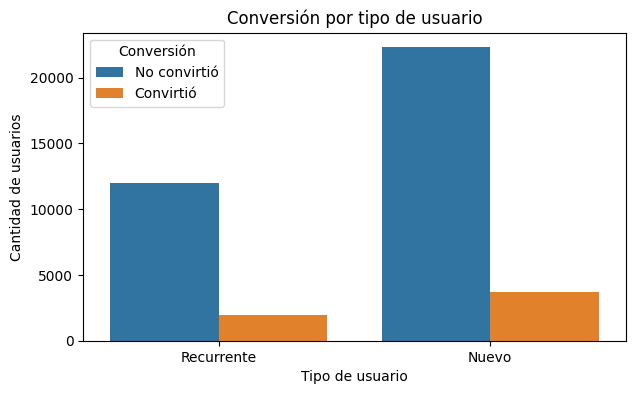

In [78]:
# Conteo de usuarios por tipo de usuario y conversión
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="user_type", hue="converted")

plt.title("Conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Cantidad de usuarios")
plt.legend(title="Conversión", labels=["No convirtió", "Convirtió"])
plt.show()

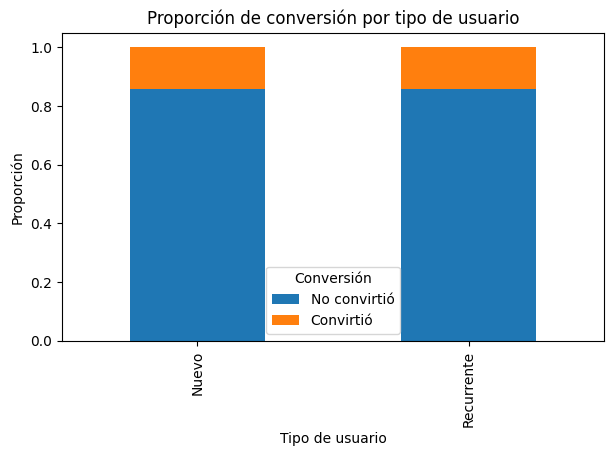

In [79]:
# Proporción de conversión por tipo de usuario
tabla_usuario_prop = pd.crosstab(
    df["user_type"],
    df["converted"],
    normalize="index"
)

tabla_usuario_prop.plot(kind="bar", stacked=True, figsize=(7, 4))

plt.title("Proporción de conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Proporción")
plt.legend(title="Conversión", labels=["No convirtió", "Convirtió"])
plt.show()

✍️ **Comentario**:

Los gráficos muestran que la conversión entre usuarios nuevos y recurrentes es muy similar. Aunque los usuarios nuevos presentan una tasa de conversión ligeramente mayor, la diferencia visual es pequeña.

Esto coincide con la prueba chi-cuadrada realizada previamente, donde no se encontró evidencia estadística suficiente para afirmar que el tipo de usuario esté asociado de manera significativa con la conversión.

<div class="alert alert-block alert-success">
<b>Graficos Clave</b> <a class="tocSkip"></a>

Los graficos son claros, informativos y estan bien construidos. 

Además, los comentarios son muy buenos. 

Excelente trabajo!

</div>

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

La página A presentó un gasto promedio aproximado de 61.09 por usuario convertido.


La página B presentó un gasto promedio aproximado de 68.75 por usuario convertido.

- **Interpretación:**
  
   La página B genera un mayor valor económico por usuario convertido.
Además, la prueba t mostró evidencia estadística de una diferencia significativa en el gasto promedio entre ambas páginas, por lo que la diferencia observada no parece deberse al azar.

<br>

**Tasa de conversión:** 

La página A presentó una tasa de conversión aproximada de 0.1257

La página B presentó una tasa de conversión aproximada de 0.1596.

- **Interpretación:**
 La página B convierte mejor que la página A, con una diferencia aproximada de 3.38 puntos porcentuales.

La prueba z de proporciones confirmó que esta diferencia es estadísticamente significativa.

#### 📊 **Segmentación por fuente de tráfico**
- Las fuentes con mejor tasa de conversión fueron Email con aproximadamente 0.1499 y Ads con aproximadamente 0.1474.


- Las fuentes con menor tasa de conversión fueron Referral con aproximadamente 0.1388 y Organic con aproximadamente 0.1379.


- **Interpretación:**

La prueba chi-cuadrada indicó que existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión. 

Esto sugiere que el canal por el que llega el usuario puede estar relacionado con su probabilidad de convertir.

#### 📊 **Segmentación por tipo de usuario**
- Los usuarios nuevos presentaron una tasa de conversión aproximada de 0.1436.

- Los usuarios recurrentes presentaron una tasa de conversión aproximada de 0.1409.

  
- **Interpretación:**

  
Aunque los usuarios nuevos muestran una tasa ligeramente mayor, la diferencia es pequeña.

La prueba chi-cuadrada no encontró evidencia estadística suficiente para afirmar que el tipo de usuario esté asociado de manera significativa con la conversión.

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

- Implementar la página B como versión principal de la landing page, ya que mostró mejor desempeño tanto en tasa de conversión como en gasto promedio por usuario convertido.


- Priorizar el análisis y optimización de los canales Email y Ads, ya que presentan las tasas de conversión más altas dentro del experimento.


- Mantener una estrategia general para usuarios nuevos y recurrentes, ya que no se encontró evidencia estadística suficiente para afirmar que el tipo de usuario influya significativamente en la conversión.


- Continuar monitoreando el experimento con nuevos datos para validar si los resultados se mantienen en el tiempo y evaluar si la mejora observada genera impacto económico suficiente para justificar la implementación definitiva.